In [1]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, f1_score
)

# Load the raw CSV
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(df.dtypes.head(10))

Shape: (7043, 21)
customerID         object
gender             object
SeniorCitizen       int64
Partner            object
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
OnlineSecurity     object
dtype: object


In [10]:
# Convert TotalCharges to numeric (it has empty spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with 0 (customers with tenure 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert target to binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Feature engineering: average monthly spend
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Feature engineering: new customer (less than 12 months)
df['is_new_customer'] = (df['tenure'] < 12).astype(int)

# Feature engineering: monthly contract flag
df['is_monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)

print(f'TotalCharges nulls after conversion: {df["TotalCharges"].isna().sum()}')
print(df[['tenure', 'TotalCharges', 'avg_monthly_spend', 'Churn']].head())

TotalCharges nulls after conversion: 0
   tenure  TotalCharges  avg_monthly_spend  Churn
0       1         29.85          29.850000      0
1      34       1889.50          55.573529      0
2       2        108.15          54.075000      0
3      45       1840.75          40.905556      0
4       2        151.65          75.825000      0


In [11]:
# Numeric features to keep as-is
features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend',
    'is_new_customer', 'is_monthly_contract', 'SeniorCitizen'
]

# Categorical features to one-hot encode
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod'
]

# One-hot encode categorical columns (drop first to avoid multicollinearity)
df_encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Combine numeric and encoded features
X = pd.concat([df[features], df_encoded], axis=1)
y = df['Churn']

print(f'Shape of X: {X.shape}')
print(f'Distribution of y: {y.value_counts(normalize=True).to_dict()}')
print(X.head())

Shape of X: (7043, 20)
Distribution of y: {0: 1.0}
   tenure  MonthlyCharges  TotalCharges  avg_monthly_spend  is_new_customer  \
0       1           29.85         29.85          29.850000                1   
1      34           56.95       1889.50          55.573529                0   
2       2           53.85        108.15          54.075000                1   
3      45           42.30       1840.75          40.905556                0   
4       2           70.70        151.65          75.825000                1   

   is_monthly_contract  SeniorCitizen  gender_Male  Partner_Yes  \
0                    1              0        False         True   
1                    0              0         True        False   
2                    1              0         True        False   
3                    0              0         True        False   
4                    1              0        False        False   

   Dependents_Yes  PhoneService_Yes  InternetService_Fiber optic  \
0  

In [4]:
# Split into train (80%) and test (20%), stratified by target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline: always predict 0 (no churn)
baseline_pred = np.zeros(len(y_test))

# Compute metrics for the trivial model
print(f'Baseline F1: {f1_score(y_test, baseline_pred):.4f}')
print(f'Baseline AUC: {roc_auc_score(y_test, baseline_pred):.4f}')

Baseline F1: 0.0000
Baseline AUC: 0.5000


In [12]:
# Logistic Regression with feature scaling
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Random Forest with class balancing
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ))
])

# Stratified K-Fold: keeps class proportion in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare both models using cross-validation
for name, pipe in [('Logistic Regression', pipe_lr), ('Random Forest', pipe_rf)]:
    f1_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f'{name} - mean F1: {f1_scores.mean():.4f} | mean AUC: {auc_scores.mean():.4f}')

Logistic Regression - mean F1: 0.6288 | mean AUC: 0.8433
Random Forest - mean F1: 0.5482 | mean AUC: 0.8201


In [13]:
# Hyperparameter grid for Random Forest
param_grid = {
    'clf__n_estimators': [100, 200, 300],       # number of trees
    'clf__max_depth': [None, 10, 20],           # maximum depth
    'clf__min_samples_split': [2, 5, 10]        # minimum samples to split
}

# GridSearchCV with 5-fold stratified cross-validation
grid = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Run the search
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best AUC: {grid.best_score_:.4f}')

Best parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Best AUC: 0.8416


In [14]:
# Get the best model from GridSearchCV
best_model = grid.best_estimator_

# Retrain on the full training set (GridSearchCV uses folds)
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Full classification report
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['No churn', 'Churn']))

# Confusion matrix
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

    No churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Confusion matrix:
[[811 224]
 [ 99 275]]


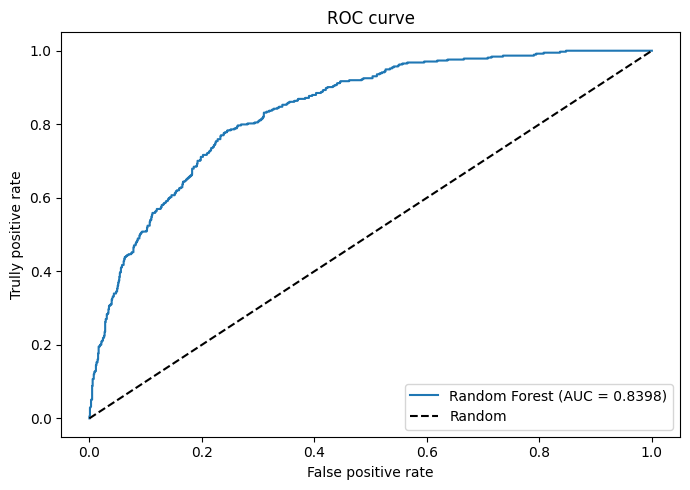

In [15]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False positive rate')
plt.ylabel('Trully positive rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

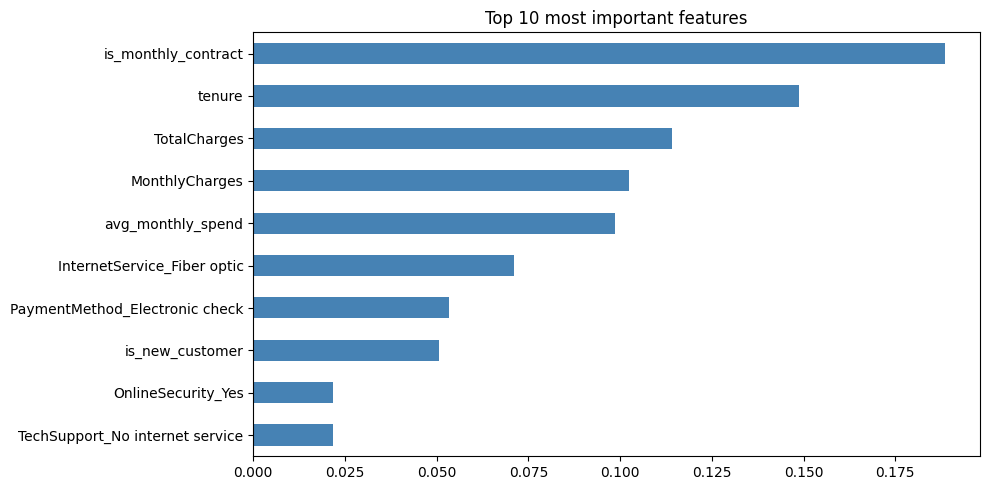

In [17]:
# Feature importance from the Random Forest inside the pipeline
importances = best_model.named_steps['clf'].feature_importances_

# Build a Series and take the top 10
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 10 most important features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()